In [1]:
# VS Code uses KaTeX, which cannot render R's LaTeX list environments.
# Keep HTML/text tables and image plots; apply again on every kernel restart.
options(jupyter.display_mimetypes = setdiff(
    getOption("jupyter.display_mimetypes", c("text/plain", "text/html", "text/markdown", "image/png", "image/jpeg", "image/svg+xml", "application/pdf")),
    "text/latex"
))

library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(harmony)
library(paletteer)
packageVersion("paletteer")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.3 but the current
version is 1.7.5; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: Rcpp

• This is Harmony2 version 2.0.5
• Read the guide: run vignette("quickstart", package="harmony")
• Get help: Visit the website at <https://korsunskylab.github.io/harmony2/> and
report issues on <https://github.com/immunogenomics/harmony/issues>


[1] ‘1.7.0’

In [2]:
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(RColorBrewer)

In [3]:
VIO<-readRDS(file='/Users/alex/Library/CloudStorage/OneDrive-Personal/A1_RioLab/01_Projects/02_Codes/1_CIVA/F1_VIO.rds')

In [4]:
# View the exact R call string and parameters
VIO@commands$RunPCA@params
VIO@commands$RunUMAP@params

$assay
[1] "RNA"

$npcs
[1] 50

$rev.pca
[1] FALSE

$weight.by.var
[1] TRUE

$verbose
[1] TRUE

$ndims.print
[1] 1 2 3 4 5

$nfeatures.print
[1] 30

$reduction.name
[1] "pca"

$reduction.key
[1] "PC_"

$seed.use
[1] 42

$dims
 [1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
[26] 26 27 28 29 30

$reduction
[1] "pca"

$assay
[1] "RNA"

$slot
[1] "data"

$umap.method
[1] "uwot"

$return.model
[1] FALSE

$n.neighbors
[1] 30

$n.components
[1] 2

$metric
[1] "cosine"

$learning.rate
[1] 1

$min.dist
[1] 0.3

$spread
[1] 1

$set.op.mix.ratio
[1] 1

$local.connectivity
[1] 1

$repulsion.strength
[1] 1

$negative.sample.rate
[1] 5

$uwot.sgd
[1] FALSE

$seed.use
[1] 42

$angular.rp.forest
[1] FALSE

$densmap
[1] FALSE

$dens.lambda
[1] 2

$dens.frac
[1] 0.3

$dens.var.shift
[1] 0.1

$verbose
[1] TRUE

$reduction.name
[1] "umap"

In [5]:
# View the summary stats (Min, Median, Max, etc.) for counts and features
summary(VIO@meta.data[, c("nCount_RNA", "nFeature_RNA")])

# Check the maximum mitochondrial percentage left in the dataset
max(VIO$percent.mt) 
# Or if you used the other column shown in your console:
max(VIO$subsets_Mito_percent)

   nCount_RNA      nFeature_RNA  
 Min.   :  2000   Min.   :  518  
 1st Qu.: 12105   1st Qu.: 4149  
 Median : 22914   Median : 5695  
 Mean   : 28570   Mean   : 5576  
 3rd Qu.: 40263   3rd Qu.: 6953  
 Max.   :225605   Max.   :12744  

[1] 14.97036

[1] 14.97036

In [6]:
colnames(VIO@meta.data)

[1] "orig.ident"           "nCount_RNA"           "nFeature_RNA"        
 [4] "subsets_Mito_percent" "subsets_Ribo_percent" "RNA_snn_res.1.2"     
 [7] "percent.mt"           "RNA_snn_res.0.5"      "seurat_clusters"     
[10] "RNA_snn_res.0.3"      "cell_type"

In [7]:
VIO$cell_type <- dplyr::recode(
  VIO$cell_type,
  "Stromal-1" = "Epithelium-1",
  "Stromal-2" = "Epithelium-2"
)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


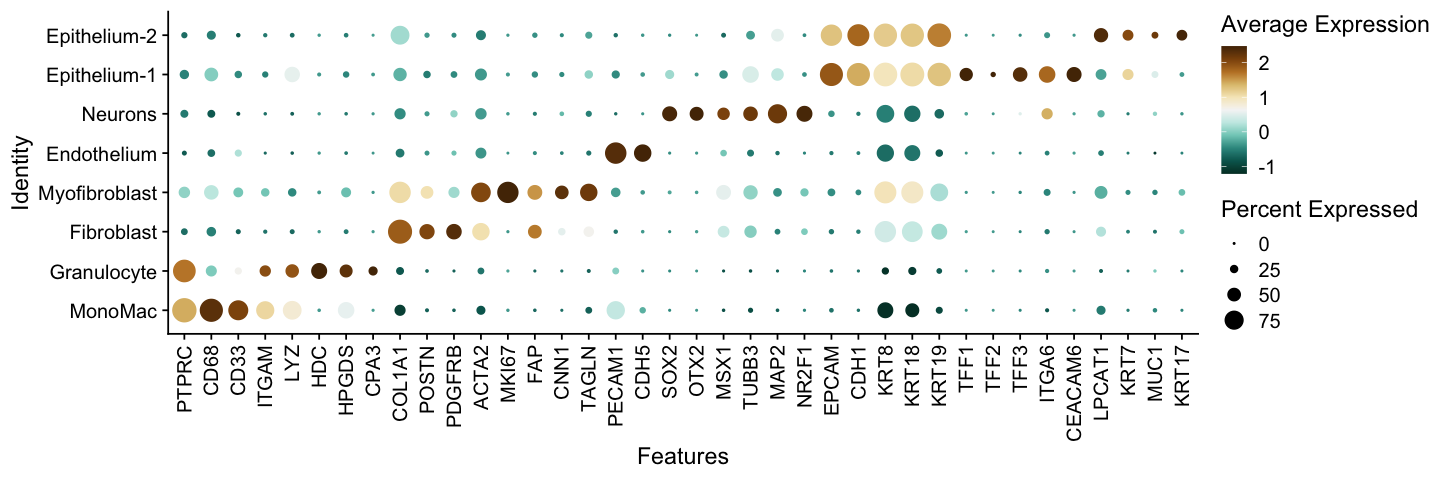

In [8]:
options(repr.plot.width=12, repr.plot.height=4)
DotPlot(VIO,features=c('PTPRC','CD68','CD33','ITGAM','LYZ','HDC','HPGDS','CPA3','COL1A1','POSTN','PDGFRB',
                       'ACTA2','MKI67','FAP','CNN1','TAGLN','PECAM1','CDH5','SOX2','OTX2','MSX1','TUBB3','MAP2',
                       'NR2F1',
                       'EPCAM','CDH1','KRT8','KRT18','KRT19',
                       'TFF1','TFF2','TFF3','ITGA6',
                       'CEACAM6','LPCAT1','KRT7','MUC1','KRT17'
                       ), group.by='cell_type') + 
scale_colour_gradientn(colours = rev(brewer.pal(n = 11, name = "BrBG"))) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) 

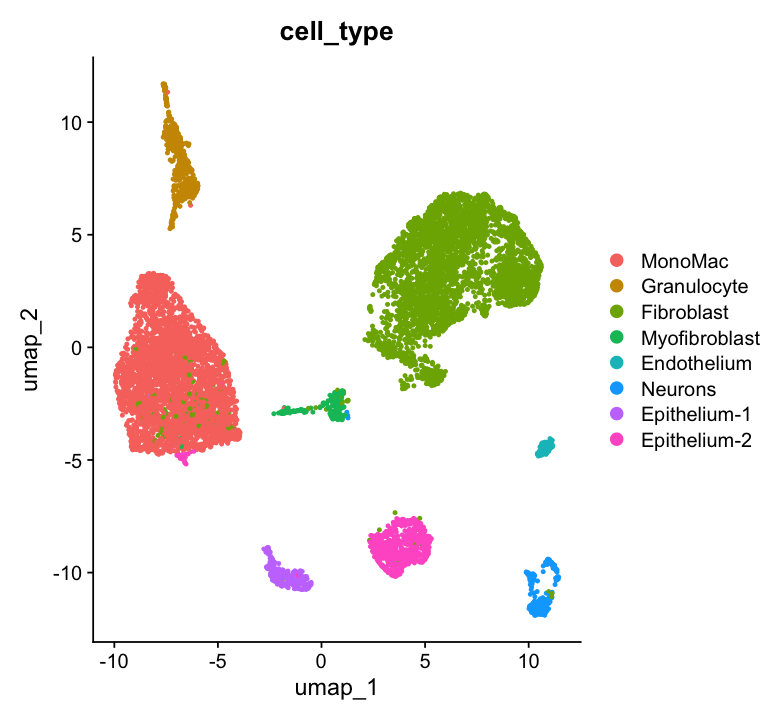

In [20]:
options(repr.plot.width=6.5, repr.plot.height=6)
DimPlot(VIO, group.by = 'cell_type', label = FALSE, label.size = 6, pt.size = 0.6, repel=TRUE) 

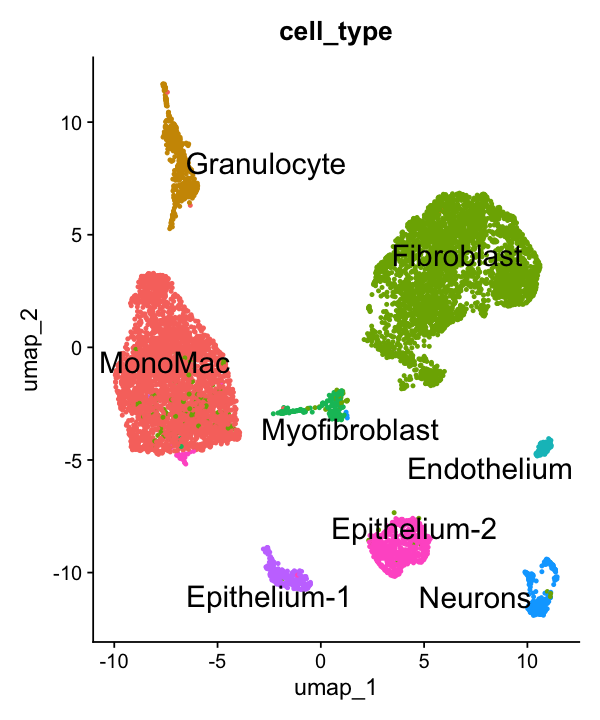

In [27]:
options(repr.plot.width=5, repr.plot.height=6)
DimPlot(VIO, group.by = 'cell_type', label = TRUE, label.size = 6.3, pt.size = 0.6, repel=TRUE) + NoLegend()

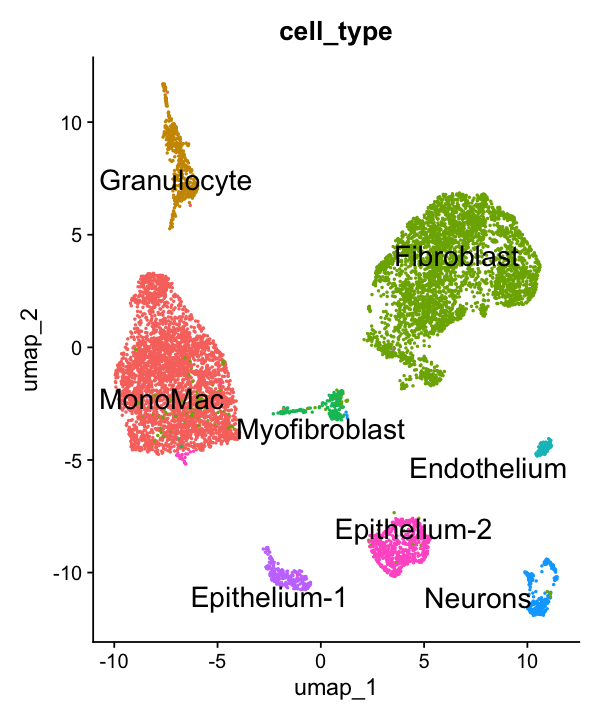

In [9]:
options(repr.plot.width=5, repr.plot.height=6)
DimPlot(VIO, group.by = 'cell_type', label = TRUE, label.size = 6, repel=TRUE) + NoLegend()

In [10]:
# Myeloid subpopulation

In [11]:
mac_subset <- subset(VIO, subset = cell_type == "MonoMac") 

DefaultAssay(mac_subset) <- "RNA"
mac_subset <- NormalizeData(mac_subset, verbose = FALSE) 
mac_subset <- FindVariableFeatures(mac_subset, selection.method = "vst", nfeatures = 2000, verbose = FALSE) # [8]
mac_subset <- RunPCA(mac_subset, npcs = 30, verbose = FALSE) # [8]

mac_subset <- FindNeighbors(mac_subset, dims = 1:30) 
mac_subset <- FindClusters(mac_subset, resolution = 0.3) 
mac_subset <- RunUMAP(mac_subset, dims = 1:30) 

Warning message:
“The `slot` argument of `SetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“Number of dimensions changing from 50 to 30”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 3423
Number of edges: 140332

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8346
Number of communities: 6
Elapsed time: 0 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
16:22:06 UMAP embedding parameters a = 0.9922 b = 1.112

16:22:06 Read 3423 rows and found 30 numeric columns

16:22:06 Using Annoy for neighbor search, n_neighbors = 30

16:22:06 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:22:06 Writing NN index file to temp file /var/folders/4t/rg4j3ld147l36_20wbl0wjxh0000gn/T//Rtmp9M23XP/file16ebe2524e33a

16:22:06 Searching Annoy index using 1 thread, search_k = 3000

16:22:07 Annoy recall = 100%

16:22:07 Commencing smooth kNN distance calibra

In [12]:
# 1. Define the identity mapping vector
id_map <- c(
  `0` = "HomoMac",
  `1` = "FABP5+ Mac",
  `2` = "MERTK+ Mac",
  `3` = "S100A8+ Mac",
  `4` = "FOLR2+ Mac",
  `5` = "FCN1+ Mac"
)

# 2. Map from active Idents and explicitly force cell barcodes as vector names
cell_labels <- id_map[as.character(Idents(mac_subset))]
names(cell_labels) <- names(Idents(mac_subset))

# 3. Create the cell_type column from scratch
mac_subset$cell_type <- cell_labels

# 4. Enforce the exact factor levels to match the original DotPlot (bottom to top)
plot_order <- c(
  "HomoMac",
  "S100A8+ Mac",
  "FCN1+ Mac",
  "FOLR2+ Mac",
  "FABP5+ Mac",
  "MERTK+ Mac"
)
mac_subset$cell_type <- factor(mac_subset$cell_type, levels = plot_order)

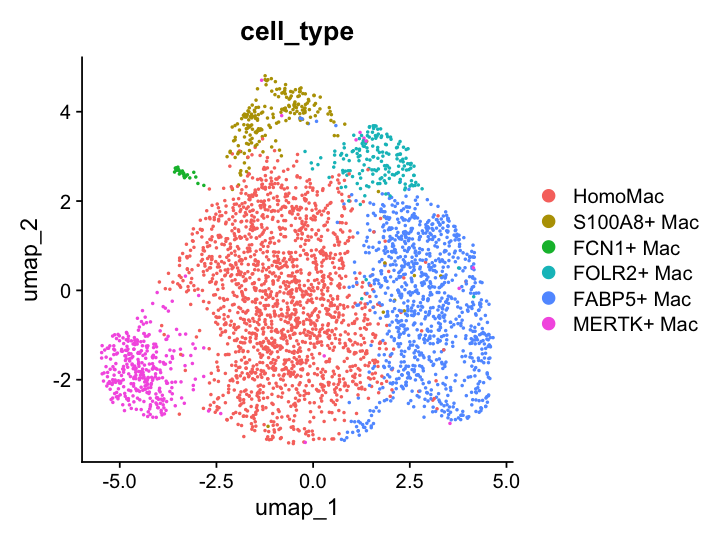

In [13]:
options(repr.plot.height=4.5, repr.plot.width=6)
DimPlot(mac_subset, group.by="cell_type", pt.size=0.2)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


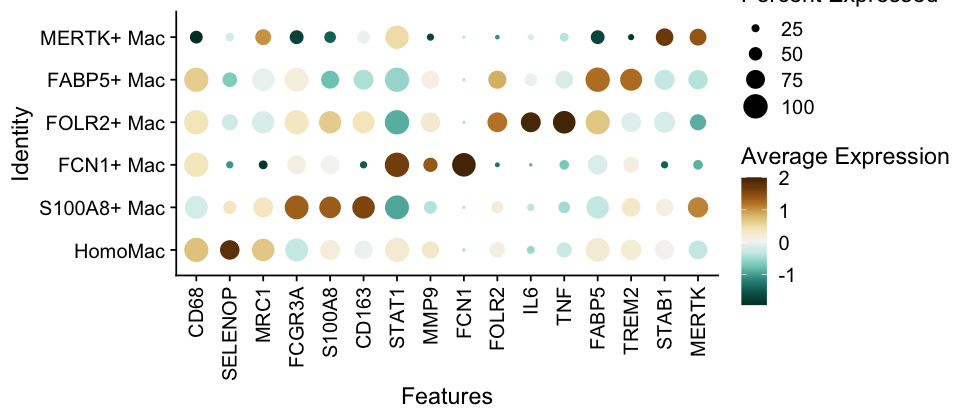

In [14]:
options(repr.plot.height=3.5, repr.plot.width=8)
DotPlot(mac_subset, group.by="cell_type",features=c(
    "CD68", "SELENOP","MRC1",
    "FCGR3A","S100A8","CD163",
    "STAT1","MMP9","FCN1",
    "FOLR2","IL6","TNF",
    "FABP5","TREM2",
    "STAB1","MERTK"
  ), col.min=-2,col.max=2)+ 
scale_colour_gradientn(colours = rev(brewer.pal(n = 11, name = "BrBG"))) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) 

In [15]:
# Fibroblast subpopulation

Warning message:
“Number of dimensions changing from 50 to 20”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4051
Number of edges: 130952

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8981
Number of communities: 7
Elapsed time: 0 seconds


16:22:22 UMAP embedding parameters a = 0.9922 b = 1.112

16:22:22 Read 4051 rows and found 20 numeric columns

16:22:22 Using Annoy for neighbor search, n_neighbors = 30

16:22:22 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:22:22 Writing NN index file to temp file /var/folders/4t/rg4j3ld147l36_20wbl0wjxh0000gn/T//Rtmp9M23XP/file16ebe1715e613

16:22:22 Searching Annoy index using 1 thread, search_k = 3000

16:22:23 Annoy recall = 100%

16:22:23 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

16:22:24 Initializing from normalized Laplacian + noise (using RSpectra)

16:22:24 Commencing optimization for 500 epochs, with 157986 positive edges

16:22:24 Using rng type: pcg

16:22:30 Optimization finished



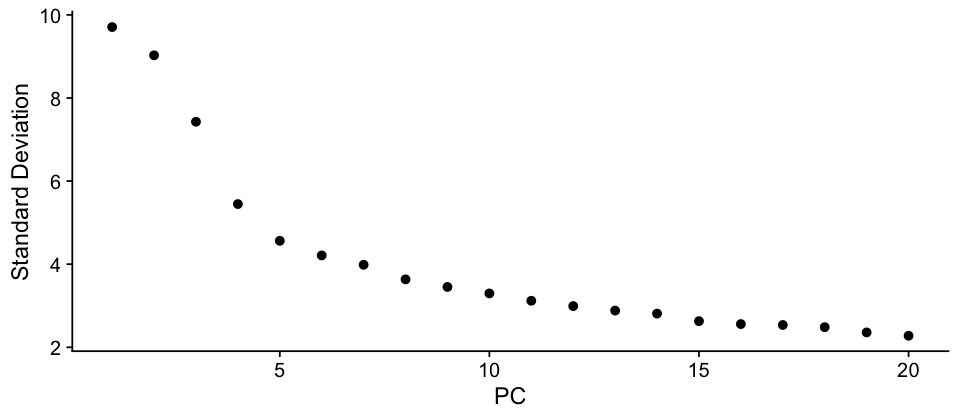

In [16]:
fib_subset <- subset(VIO, subset = cell_type %in% c("Fibroblast", "Myofibroblast")) 

DefaultAssay(fib_subset) <- "RNA"
fib_subset <- NormalizeData(fib_subset, verbose = FALSE) 
fib_subset <- FindVariableFeatures(fib_subset, selection.method = "vst", nfeatures = 2000, verbose = FALSE) # [8]
fib_subset <- RunPCA(fib_subset, npcs = 20, verbose = FALSE) # [8]

# (Optional) Visualize PCA elbow plot to choose dimensions
ElbowPlot(fib_subset)

fib_subset <- FindNeighbors(fib_subset, dims = 1:20) 
fib_subset <- FindClusters(fib_subset, resolution = 0.2) 
fib_subset <- RunUMAP(fib_subset, dims = 1:20) 

In [17]:
Idents(fib_subset) <- "seurat_clusters"

fib_subset <- RenameIdents(
  fib_subset,
  `5` = "Macrophages",
  `0` = "Neuronal-like",
  `3` = "Epithelium",          # adjust if a different cluster is Epithelium
  `1` = "Myofibroblasts",
  `2` = "POSTN+ Fibroblast",
  `4` = "MKI67+ Fibroblast",   # adjust if needed
  `6` = "PDGFRB+ Fibroblast"
)
Idents(fib_subset) <- factor(
  Idents(fib_subset),
  levels = c(
    "Macrophages",
    "Neuronal-like",
    "Epithelium",
    "Myofibroblasts",
    "POSTN+ Fibroblast",
    "MKI67+ Fibroblast",
    "PDGFRB+ Fibroblast"
  )
)

levels(Idents(fib_subset))
# [1] "Macrophages" "Neuronal-like" "Epithelium" "Myofibroblasts"
#     "POSTN+ Fibroblast" "MKI67+ Fibroblast" "PDGFRB+ Fibroblast"


[1] "Macrophages"        "Neuronal-like"      "Epithelium"        
[4] "Myofibroblasts"     "POSTN+ Fibroblast"  "MKI67+ Fibroblast" 
[7] "PDGFRB+ Fibroblast"

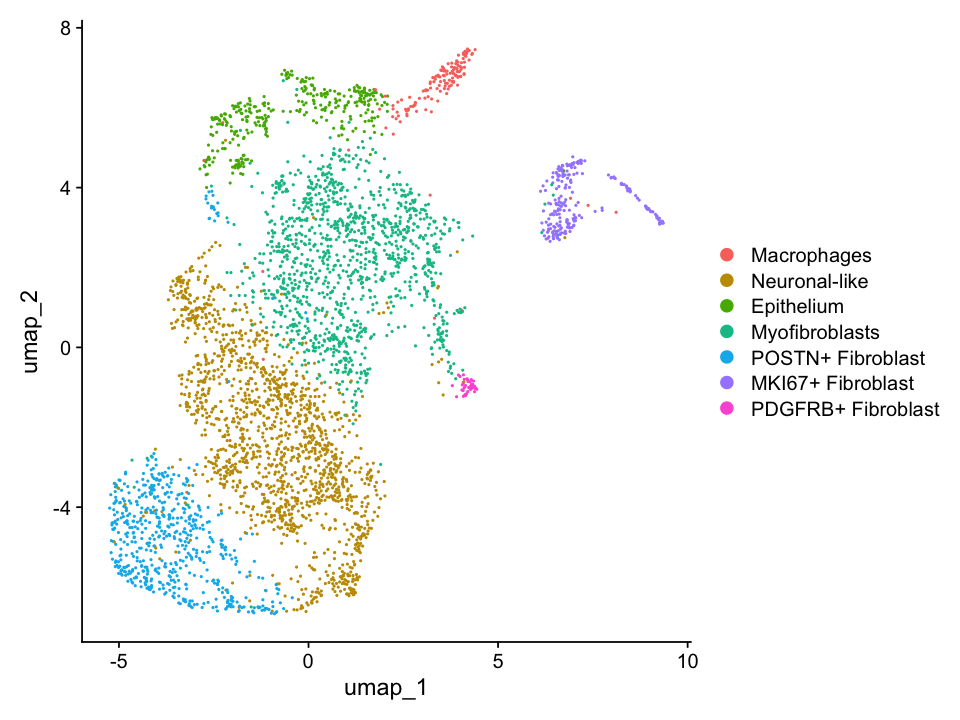

In [18]:
options(repr.plot.height=6, repr.plot.width=8)
DimPlot(fib_subset, pt.size=0.1)

Warning message:
“The following requested variables were not found: CNTNBP2”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


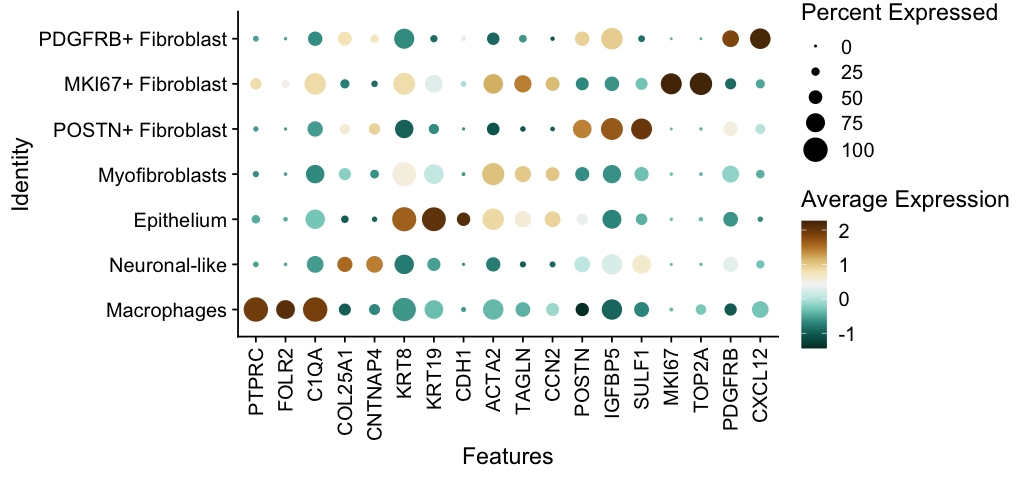

In [21]:
options(repr.plot.width = 8.5, repr.plot.height = 4)

DotPlot(
  fib_subset,
  features = c(
  "PTPRC", "FOLR2", "C1QA",
  "COL25A1", "CNTNAP4", "CNTNBP2",
  "KRT8", "KRT19", "CDH1",
  "ACTA2", "TAGLN", "CCN2",
  "POSTN", "IGFBP5", "SULF1",
  "MKI67", "TOP2A",
  "PDGFRB", "CXCL12"
  )
) +
  scale_colour_gradientn(
    colours = rev(brewer.pal(n = 11, name = "BrBG"))
  ) +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)
  )